In [4]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

df = pd.read_csv("/content/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.info()
df.columns
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
# # exercice 1
# Nombre de lignes avant suppression
rows_before = df.shape[0]

# Identifier les lignes dupliquées
duplicates = df.duplicated().sum()

print("Nombre de lignes avant suppression :", rows_before)
print("Nombre de lignes dupliquées :", duplicates)

Nombre de lignes avant suppression : 891
Nombre de lignes dupliquées : 0


Dans cet exercice, nous avons utilisé `duplicated()` pour identifier les lignes dupliquées dans le dataset Titanic. Ensuite, `drop_duplicates()` aurait été utilisée pour supprimer les doublons. Le nombre de lignes avant suppression permet de vérifier si des doublons existaient réellement dans le dataset. mais nous n'avions aucune ligne dupliquer

Exercice 2 — Handling Missing Values

In [17]:
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


suppression de la colonne cabine car il y'a trop de valeurs manquantes

In [16]:
df = df.drop(columns=["Cabin"])

remplissons la colonne `age` avec la mediane

In [18]:
age_imputer = SimpleImputer(strategy="median")

df["Age"] = age_imputer.fit_transform(df[["Age"]])

Remplir Embarked avec la valeur la plus fréquente

In [19]:
embarked_imputer = SimpleImputer(strategy="most_frequent")

df["Embarked"] = embarked_imputer.fit_transform(df[["Embarked"]]).ravel()

je verifie de nouveau dataset pour voir s'il y'a des données manquantes

In [20]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Les valeurs manquantes ont été traitées selon la nature des colonnes. La colonne `Cabin` a été supprimée car elle contient trop de valeurs manquantes. La colonne `Age`, qui est numérique, a été remplie avec la médiane. La colonne `Embarked`, qui est catégorielle, a été remplie avec la valeur la plus fréquente.

Exercice 3 — Feature Engineering

In [21]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [22]:
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

df[["Name", "Title"]].head()

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [23]:
df["Title"].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [24]:
title_encoded = pd.get_dummies(df["Title"], prefix="Title")

title_encoded.head()

,Title_Capt,Title_Col,Title_Countess,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [25]:
df = pd.concat([df, title_encoded], axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,False,False,False,False,False,True,False,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,False,False,False,False,False,False,True,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,False,False,True,False,False,False,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,False,False,False,False,False,False,True,False,False,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,False,False,False,False,False,True,False,False,False,False


Deux nouvelles variables ont été créées. `FamilySize` représente la taille de la famille à bord du Titanic à partir de `SibSp` et `Parch`. La colonne `Title` a été extraite depuis la colonne `Name`, car les titres comme Mr, Mrs, Miss ou Master peuvent donner des informations utiles sur le profil des passagers.

Exercice 4 — Outlier Detection and Handling

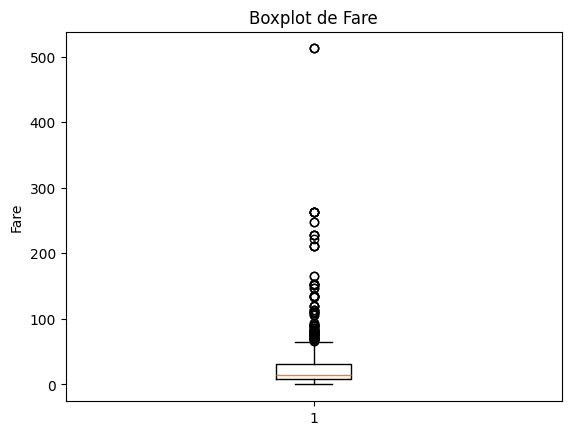

In [26]:
plt.boxplot(df["Fare"])
plt.title("Boxplot de Fare")
plt.ylabel("Fare")
plt.show()

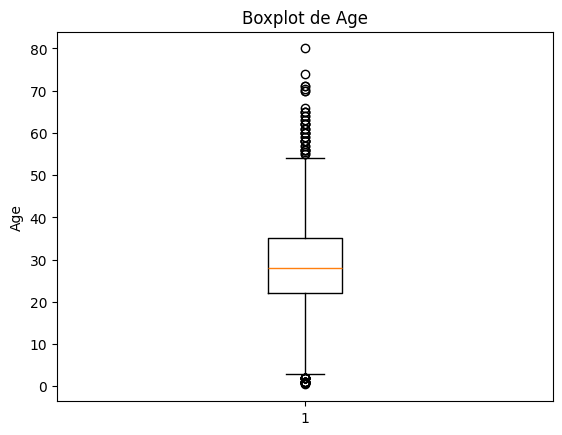

In [27]:
plt.boxplot(df["Age"])
plt.title("Boxplot de Age")
plt.ylabel("Age")
plt.show()

In [28]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return lower_bound, upper_bound, outliers

In [29]:
fare_lower, fare_upper, fare_outliers = detect_outliers_iqr(df, "Fare")

print("Limite basse Fare :", fare_lower)
print("Limite haute Fare :", fare_upper)
print("Nombre d'outliers Fare :", fare_outliers.shape[0])

Limite basse Fare : -26.724
Limite haute Fare : 65.6344
Nombre d'outliers Fare : 116


In [30]:
age_lower, age_upper, age_outliers = detect_outliers_iqr(df, "Age")

print("Limite basse Age :", age_lower)
print("Limite haute Age :", age_upper)
print("Nombre d'outliers Age :", age_outliers.shape[0])

Limite basse Age : 2.5
Limite haute Age : 54.5
Nombre d'outliers Age : 66


In [31]:
fare_cap = df["Fare"].quantile(0.98)
age_cap = df["Age"].quantile(0.98)

df["Fare_capped"] = np.where(df["Fare"] > fare_cap, fare_cap, df["Fare"])
df["Age_capped"] = np.where(df["Age"] > age_cap, age_cap, df["Age"])

df[["Fare", "Fare_capped", "Age", "Age_capped"]].head()

,Fare,Fare_capped,Age,Age_capped
0,7.2500,7.2500,22.0,22.0
1,71.2833,71.2833,38.0,38.0
2,7.9250,7.9250,26.0,26.0
3,53.1000,53.1000,35.0,35.0
4,8.0500,8.0500,35.0,35.0


In [32]:
df["Fare_log"] = np.log1p(df["Fare"])

df[["Fare", "Fare_log"]].head()

,Fare,Fare_log
0,7.2500,2.110213
1,71.2833,4.280593
2,7.9250,2.188856
3,53.1000,3.990834
4,8.0500,2.202765


Les outliers ont été étudiés avec des boxplots et la méthode IQR. Les colonnes `Fare` et `Age` peuvent contenir des valeurs extrêmes. Pour limiter leur influence, nous avons utilisé le capping par quantile et une transformation logarithmique sur `Fare`. La transformation log est utile pour réduire l’effet des grandes valeurs.

Exercice 5 — Standardization and Normalization

StandardScaler pour Age_capped
MinMaxScaler pour Fare_capped ou Fare_log

In [33]:
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

df["Age_standardized"] = standard_scaler.fit_transform(df[["Age_capped"]])
df["Fare_normalized"] = minmax_scaler.fit_transform(df[["Fare_capped"]])

df[["Age_capped", "Age_standardized", "Fare_capped", "Fare_normalized"]].head()

,Age_capped,Age_standardized,Fare_capped,Fare_normalized
0,22.0,-0.570988,7.2500,0.034305
1,38.0,0.687580,71.2833,0.337296
2,26.0,-0.256346,7.9250,0.037499
3,35.0,0.451599,53.1000,0.251257
4,35.0,0.451599,8.0500,0.038091


Après le traitement des valeurs aberrantes, les variables numériques ont été mises à l’échelle. `Age_capped` a été standardisée avec `StandardScaler`, tandis que `Fare_capped` a été normalisée avec `MinMaxScaler`. Cette étape prépare les données pour de futurs modèles de machine learning.

Exercice 6 — Feature Encoding

In [34]:
categorical_columns = df.select_dtypes(include=["object"]).columns

categorical_columns

Index(['Name', 'Sex', 'Ticket', 'Embarked', 'Title'], dtype='object')

In [35]:
encoded_cols = pd.get_dummies(df[["Sex", "Embarked"]], drop_first=True)

encoded_cols.head()

,Sex_male,Embarked_Q,Embarked_S
0,True,False,True
1,False,False,False
2,False,False,True
3,False,False,True
4,True,False,True


In [36]:
df = pd.concat([df, encoded_cols], axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Rev,Title_Sir,Fare_capped,Age_capped,Fare_log,Age_standardized,Fare_normalized,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,False,False,7.2500,22.0,2.110213,-0.570988,0.034305,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,False,False,71.2833,38.0,4.280593,0.687580,0.337296,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,False,False,7.9250,26.0,2.188856,-0.256346,0.037499,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,False,False,53.1000,35.0,3.990834,0.451599,0.251257,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,False,False,8.0500,35.0,2.202765,0.451599,0.038091,True,False,True


Les colonnes catégorielles restantes ont été identifiées avec `select_dtypes()`. Les variables nominales comme `Sex` et `Embarked` ont été encodées avec `pd.get_dummies()`. Cette transformation permet de convertir les catégories textuelles en colonnes numériques utilisables par les modèles.

Exercice 7 — Data Transformation for Age Feature

In [37]:
bins = [0, 12, 18, 60, 100]
labels = ["Child", "Teen", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

df[["Age", "AgeGroup"]].head()

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


In [38]:
age_group_encoded = pd.get_dummies(df["AgeGroup"], prefix="AgeGroup")

age_group_encoded.head()

,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,False,False,True,False
1,False,False,True,False
2,False,False,True,False
3,False,False,True,False
4,False,False,True,False


In [39]:
df = pd.concat([df, age_group_encoded], axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age_standardized,Fare_normalized,Sex_male,Embarked_Q,Embarked_S,AgeGroup,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,-0.570988,0.034305,True,False,True,Adult,False,False,True,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0.687580,0.337296,False,False,False,Adult,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,-0.256346,0.037499,False,False,True,Adult,False,False,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,0.451599,0.251257,False,False,True,Adult,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0.451599,0.038091,True,False,True,Adult,False,False,True,False


La variable `Age` a été transformée en groupes d’âge avec `pd.cut()`. Les catégories créées sont `Child`, `Teen`, `Adult` et `Senior`. Ensuite, ces groupes ont été encodés avec `pd.get_dummies()` afin de les convertir en variables numériques.

## Conclusion

Dans cette série d’exercices, le dataset Titanic a été préparé progressivement pour l’analyse et le machine learning. Nous avons supprimé les doublons, traité les valeurs manquantes, créé de nouvelles variables, détecté et traité les outliers, mis à l’échelle les variables numériques, encodé les variables catégorielles et transformé l’âge en groupes.

Ces étapes constituent une base importante du preprocessing en data science.